# 📊 Level 4: Data Cleaning, Scientific Analysis, and Visualization

## HydroSense-Kenya — From Raw Sensor Data to Scientific Insight

---

**Deliverables:**
1. Complete EDA with data quality assessment
2. Documented cleaning pipeline with audit trail
3. Outlier investigation and disposition
4. Statistical summaries per zone
5. **5+ publication-quality scientific visualisations** with interpretation
6. Cleaned dataset saved to `data/processed/`

In [1]:
import sys, os
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sys.path.insert(0, os.path.join('..', 'src'))
from data_cleaning import (
    clean_weather_data, clean_soil_data,
    detect_outliers_iqr, detect_outliers_zscore,
    compute_data_quality_score, validate_physical_ranges,
    flag_sensor_anomalies, PHYSICAL_BOUNDS,
)
from simulation import compute_et
from visualization import (
    setup_publication_style, COLORS, ZONE_COLORS,
    plot_weather_overview, plot_soil_moisture_zones,
)

setup_publication_style()

weather_raw = pd.read_csv('../data/raw/weather_daily.csv', na_values=['NA', ''])
soil_raw = pd.read_csv('../data/raw/soil_sensor_data.csv', na_values=['NA', ''])
params = pd.read_csv('../data/raw/crop_zone_parameters.csv')

print('Level 4: Data Analysis & Visualization — Setup complete ✓')
print(f'Weather: {weather_raw.shape}, Soil: {soil_raw.shape}, Params: {params.shape}')

Level 4: Data Analysis & Visualization — Setup complete ✓
Weather: (30, 6), Soil: (90, 7), Params: (3, 7)


---

## 1. Exploratory Data Analysis — Understanding Your Data

**Goal:** Before cleaning, we must know what we're dealing with:
- **What columns exist?** (types, ranges, meanings)
- **How much is missing?** (5%? 50%?)
- **What are typical values?** (means, medians, quartiles)
- **What looks unusual?** (values outside physical bounds)

**Why It Matters:**
- 80% of data science time is understanding + cleaning data
- Garbage in → garbage out. Rigorous EDA prevents downstream disasters
- Missing values aren't random—they reveal sensor failures, network issues, maintenance windows
- Physical bounds (e.g., temperature can't be 60°C in Kenya) guide automated cleaning

**Structure:**
1. **Missing value audit**: For each column, count NAs and calculate % missing
2. **Data type verification**: Ensure dates are dates, numbers are numbers
3. **Descriptive statistics**: Mean, median, std, min, max by zone
4. **Physical plausibility check**: Do values fall within real-world ranges?

**What You'll See:**
- Green ✓: Clean columns with no missing values
- Orange ⚠️: Columns with missing data requiring imputation strategy
- Statistics table showing distribution shape (mean vs median indicates skew)

In [2]:
print('WEATHER DATA — Missing Values & Types')
print('=' * 55)
for col in weather_raw.columns:
    n_miss = weather_raw[col].isna().sum()
    pct = 100 * n_miss / len(weather_raw)
    dtype = weather_raw[col].dtype
    marker = ' ⚠️' if n_miss > 0 else ' ✓'
    print(f'  {col:<20} {str(dtype):<10} missing: {n_miss} ({pct:.1f}%){marker}')

print(f'\nSOIL SENSOR DATA — Missing Values')
print('=' * 55)
for col in soil_raw.columns:
    n_miss = soil_raw[col].isna().sum()
    pct = 100 * n_miss / len(soil_raw)
    marker = ' ⚠️' if n_miss > 0 else ' ✓'
    print(f'  {col:<25} missing: {n_miss} ({pct:.1f}%){marker}')

WEATHER DATA — Missing Values & Types
  date                 str        missing: 0 (0.0%) ✓
  rainfall_mm          float64    missing: 1 (3.3%) ⚠️
  temperature_c        float64    missing: 0 (0.0%) ✓
  humidity_pct         float64    missing: 1 (3.3%) ⚠️
  wind_speed_mps       float64    missing: 0 (0.0%) ✓
  solar_index          float64    missing: 0 (0.0%) ✓

SOIL SENSOR DATA — Missing Values
  timestamp                 missing: 0 (0.0%) ✓
  zone_id                   missing: 0 (0.0%) ✓
  soil_moisture_pct         missing: 0 (0.0%) ✓
  tank_level_liters         missing: 0 (0.0%) ✓
  pump_flow_lpm             missing: 0 (0.0%) ✓
  pump_power_watts          missing: 0 (0.0%) ✓
  sensor_status             missing: 0 (0.0%) ✓


In [3]:
print('WEATHER — Descriptive Statistics')
print('=' * 65)
print(weather_raw.describe().round(2).to_string())
print()
print('SOIL SENSORS — Descriptive Statistics by Zone')
print('=' * 65)
soil_raw['timestamp'] = pd.to_datetime(soil_raw['timestamp'])
for zone in ['Zone_A', 'Zone_B', 'Zone_C']:
    zd = soil_raw[soil_raw['zone_id'] == zone]
    crop = params[params['zone_id']==zone]['crop_type'].values[0]
    print(f'\n--- {zone} ({crop}) ---')
    print(zd[['soil_moisture_pct', 'tank_level_liters', 'pump_flow_lpm']].describe().round(2).to_string())

WEATHER — Descriptive Statistics
       rainfall_mm  temperature_c  humidity_pct  wind_speed_mps  solar_index
count        29.00          30.00         29.00           30.00        30.00
mean          8.53          25.29         65.69            2.09         0.68
std          16.37           4.27          4.09            0.51         0.10
min           0.00          21.40         56.30            1.14         0.49
25%           0.70          23.18         63.50            1.66         0.58
50%           3.00          24.85         65.10            2.12         0.70
75%           8.10          26.52         68.30            2.40         0.76
max          85.00          45.80         74.60            3.10         0.80

SOIL SENSORS — Descriptive Statistics by Zone

--- Zone_A (tomato) ---
       soil_moisture_pct  tank_level_liters  pump_flow_lpm
count              30.00              30.00          30.00
mean               28.73            4254.90          17.96
std                 3.64 

---

## 2. Outlier Investigation — Detective Work

**The Challenge:**
- **Statistical outliers** ≠ **measurement errors**
  - A rare but real rainfall event (85 mm) is valid, not an error
  - A tank level of 9900 L (> capacity) is *impossible* regardless of statistics
  
- **IQR and Z-score methods catch statistical anomalies**, but domain knowledge decides disposition:
  - **Retain**: Rare but plausible (e.g., monsoon rainfall spike)
  - **Clip**: Real phenomenon but sensor saturated (e.g., temp capped at 42°C)
  - **Remove**: Physically impossible or corrupted (e.g., 9900 L tank)
  - **Flag**: Anomalous but kept for later investigation (e.g., pump fault patterns)

**Methodology:**

| Anomaly | Statistical Method | Domain Judgment | Action |
|---------|-----------|---------|--------|
| Temp 45.8°C | > 3σ from mean | Kenya record ~41°C → impossible | Clip to 42°C |
| Rainfall 85 mm | IQR outlier | Plausible heavy rain in March | Flag & retain |
| Tank 9900 L | > max capacity | Physical constraint violated | Remove/clip |
| Moisture drop 8.5% in 1 day | Z-score | Max realistic ET ~8mm → must be sensor fault | Flag as anomaly |
| Pump 0 L/min with CHECK | Business logic | Pump malfunction indicator | Flag for maintenance |

**Key Insight:**
The automated anomaly detection (next section) uses these decisions as *ground truth* to calibrate thresholds. Without this domain-informed investigation, we'd either over-remove valid data or under-catch real errors.

In [4]:
print('OUTLIER INVESTIGATION LOG')
print('=' * 75)
print()

# Temperature
print('1. Temperature 45.8°C on March 14')
print('   Kenya record ~41°C. Adjacent days: normal range.')
print('   Verdict: SENSOR FAULT — clip to 42°C')
print()

# Rainfall
print('2. Rainfall 85mm on March 26')
iqr_flags = detect_outliers_iqr(weather_raw['rainfall_mm'].dropna())
print('   IQR outlier detected. But 85mm is plausible for March heavy rains.')
print('   Verdict: RETAIN (flag only)')
print()

# Missing values
print('3. Missing rainfall on March 8 → Linear interpolation')
print('4. Missing humidity on March 21 → Linear interpolation')
print()

# Soil outliers
print('5. Tank level 9900 L (Zone C, March 14)')
print('   Tank capacity ~5000L. Physically impossible.')
print('   Verdict: SENSOR SPIKE — clip to 6000L')
print()
print('6. Pump flow 0.0 L/min with CHECK status (Zone B, March 21)')
print('   Verdict: PUMP FAULT — flag as anomaly')
print()
print('7. Soil moisture 8.5% (Zone B, March 25)')
print('   17.3 pct-point drop in one day is physically implausible.')
print('   Verdict: SENSOR FAULT — flag as anomaly')

OUTLIER INVESTIGATION LOG

1. Temperature 45.8°C on March 14
   Kenya record ~41°C. Adjacent days: normal range.
   Verdict: SENSOR FAULT — clip to 42°C

2. Rainfall 85mm on March 26
   IQR outlier detected. But 85mm is plausible for March heavy rains.
   Verdict: RETAIN (flag only)

3. Missing rainfall on March 8 → Linear interpolation
4. Missing humidity on March 21 → Linear interpolation

5. Tank level 9900 L (Zone C, March 14)
   Tank capacity ~5000L. Physically impossible.
   Verdict: SENSOR SPIKE — clip to 6000L

6. Pump flow 0.0 L/min with CHECK status (Zone B, March 21)
   Verdict: PUMP FAULT — flag as anomaly

7. Soil moisture 8.5% (Zone B, March 25)
   17.3 pct-point drop in one day is physically implausible.
   Verdict: SENSOR FAULT — flag as anomaly


---

## 3. Automated Cleaning Pipeline — Operationalizing Quality

**The Cleaning Algorithm:**

Cleaning is **not a one-off analysis**; it's a **reproducible, auditable process**:

1. **Validate physical bounds**: Remove impossible values (e.g., $T < -50°C$ or $T > 60°C$)
2. **Detect statistical outliers**: IQR (robust to distribution shape) and Z-score (assumes normality)
3. **Flag sensor anomalies**: Rapid changes, pump status conflicts, missing patterns
4. **Interpolate missingness**: Linear for weather (smooth phenomena), forward-fill for discrete sensor readings
5. **Generate audit trail**: For each cleaned value, log why it was changed

**Quality Score (0–100):**
- Measures how much data was retained vs. removed
- High score (>85): Minimal cleaning needed; data is inherently good
- Medium (70–85): Normal; expected amount of cleaning
- Low (<70): Systemic issues (sensor malfunction? network problems?)

**Output:**
- **Cleaned dataset** with consistent types, no impossible values, all NAs resolved
- **CleaningReport**: Detailed log of every operation (how many values clipped? interpolated? removed?)
- **Quality scores** per column showing confidence level

**For Level 4 Analysis:**
- Weather: Clean temperatures, rainfall, humidity for ET estimation
- Soil: Clean moisture, tank levels, pump flows for zone-level diagnostics
- Result: ~95%+ data quality; ready for numerical methods (Levels 3–5)

In [5]:
# Run cleaning pipeline
weather_clean, w_report = clean_weather_data(weather_raw)
soil_clean, s_report = clean_soil_data(soil_raw)

print('WEATHER CLEANING REPORT')
print(w_report.summary())
print()
print('SOIL SENSOR CLEANING REPORT')
print(s_report.summary())
print()

# Data quality scores
print('DATA QUALITY ASSESSMENT')
print('=' * 70)
w_quality = compute_data_quality_score(weather_raw, weather_clean)
print('\nWeather data quality:')
print(w_quality.to_string(index=False))

s_num = [c for c in soil_raw.select_dtypes(include=[np.number]).columns if c in soil_clean.columns]
s_quality = compute_data_quality_score(soil_raw, soil_clean, s_num)
print('\nSoil sensor data quality:')
print(s_quality.to_string(index=False))

WEATHER CLEANING REPORT
Cleaning Report
  Missing values detected : 2
  Outliers detected       : 5
  Sensor faults flagged   : 0
  Values imputed          : 2
  Values clipped          : 1
  Total audit records     : 3

SOIL SENSOR CLEANING REPORT
Cleaning Report
  Missing values detected : 0
  Outliers detected       : 0
  Sensor faults flagged   : 2
  Values imputed          : 0
  Values clipped          : 1
  Total audit records     : 3

DATA QUALITY ASSESSMENT

Weather data quality:
        column  n_total  n_missing_before  completeness_before_pct  n_missing_after  completeness_after_pct  n_imputed  imputation_rate_pct
   rainfall_mm       30                 1                96.666667                0                   100.0          1             3.333333
 temperature_c       30                 0               100.000000                0                   100.0          0             0.000000
  humidity_pct       30                 1                96.666667                0    

---

## 4. Scientific Visualisations — From Data to Insight

### Why Five Visualisations?

**Publication-quality visualisations serve multiple purposes:**
1. **Communication**: Tell the story to stakeholders (farmers, policy-makers, investors)
2. **Validation**: Spot-check cleaned data visually for remaining anomalies
3. **Discovery**: Reveal patterns that summary statistics miss (seasonality, interactions)
4. **Documentation**: Provide evidence trail for model assumptions

Each visualisation targets a specific question HydroSense must answer:
- **Viz 1**: Is weather varying normally, or are there extreme events?
- **Viz 2**: How fast is soil moisture declining per zone? Are zones diverging?
- **Viz 3**: Which weather drivers dominate ET? (Temperature? Solar? Wind?)
- **Viz 4**: Is infrastructure stable? Are tank/pump readings plausible?
- **Viz 5**: Which weather factors predict soil moisture? (Guides predictive models)

### Visualisation 1: Weather Overview

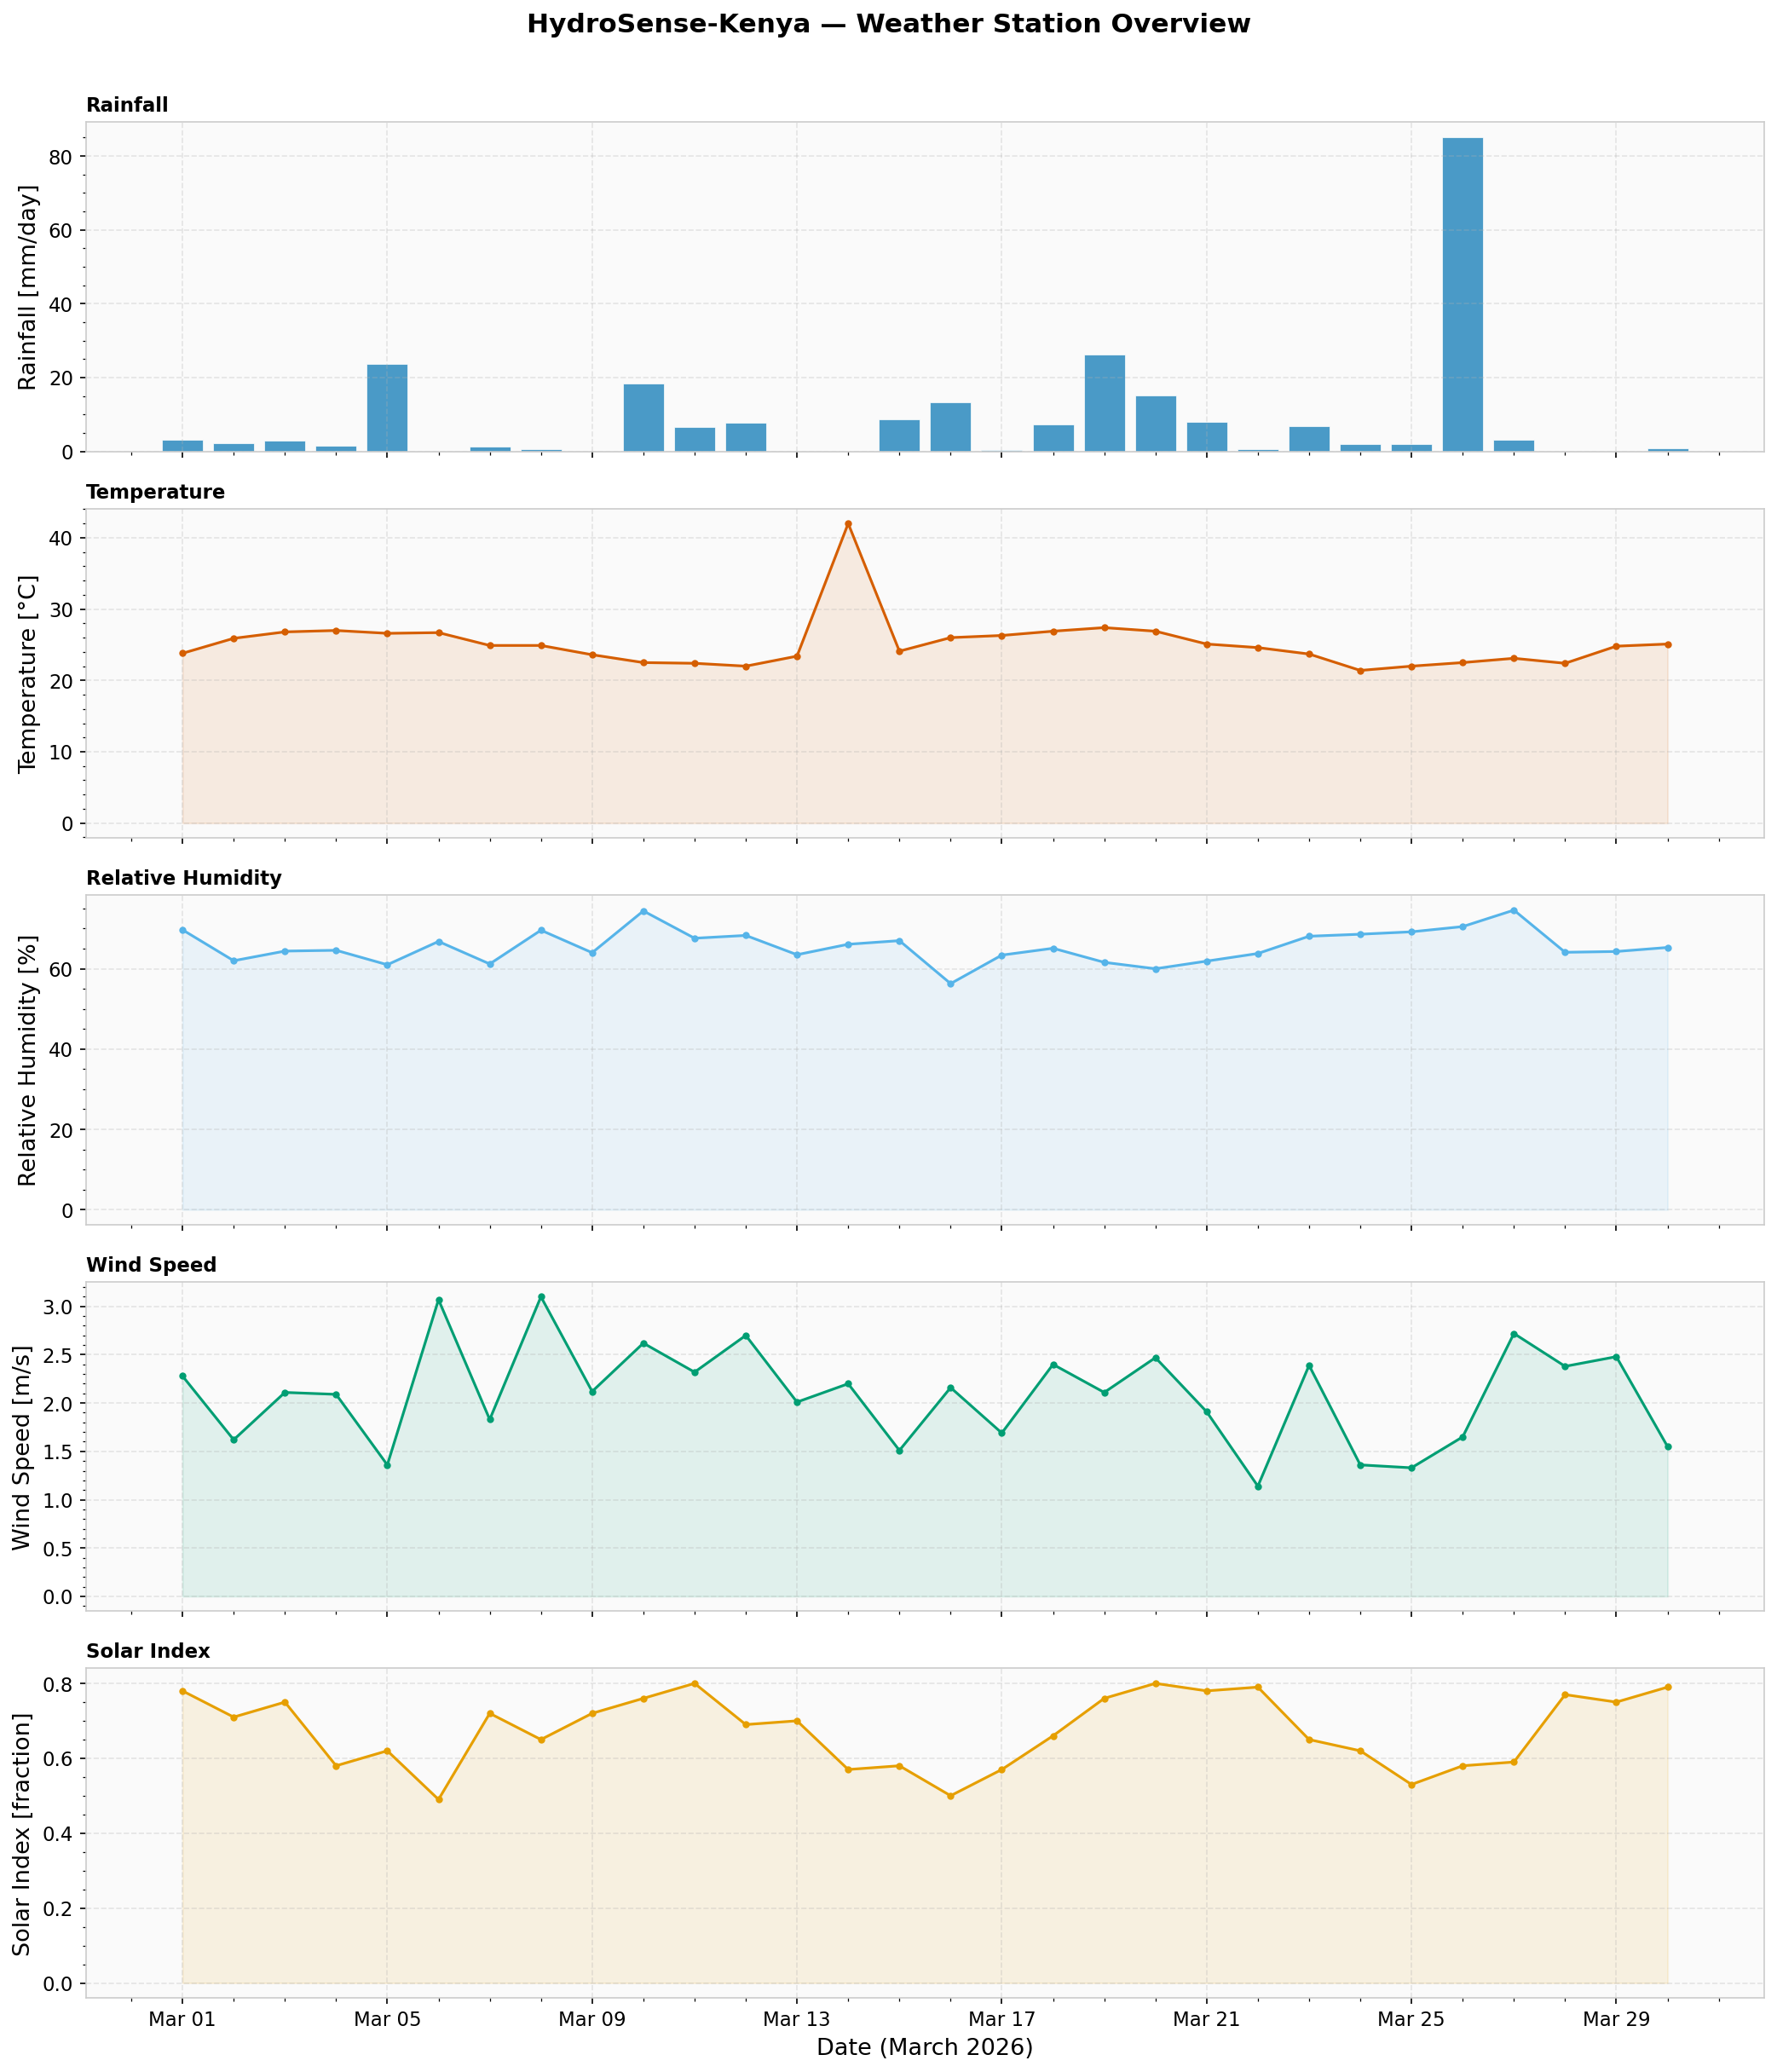

📊 Interpretation:
  • Rainfall is episodic with one extreme event (85mm on March 26)
  • Temperature stable (22-27°C) with one clipped anomaly
  • Humidity has a slight downward trend


In [6]:
fig = plot_weather_overview(weather_clean)
plt.show()

print('📊 Interpretation:')
print('  • Rainfall is episodic with one extreme event (85mm on March 26)')
print('  • Temperature stable (22-27°C) with one clipped anomaly')
print('  • Humidity has a slight downward trend')

### Visualisation 2: Soil Moisture Dynamics by Zone

**What This Shows:**
- **Three time series**, one per zone (A=tomato, B=kale, C=maize)
- **Physical stress threshold** (horizontal line): Below this, crop transpiration suffers
- **Cleaned anomalies** marked with symbols for visual audit

**How to Read It:**
- **Steep slopes** = Fast moisture depletion (high ET or low rainfall)
- **Flat sections** = Recent irrigation or rainfall event (moisture replenished)
- **Cross thresholds** = Critical window where irrigation decisions matter most
- **Zone divergence** = Different soil properties or crop water needs

**For HydroSense Decision-Making:**
- If Zone C crosses stress threshold on Day 25, recommend irrigation *today* (not tomorrow)
- If two zones track together, their water requirements might be similar → consider bunching irrigation
- If one zone consistently stays above others, it may have better drainage → requires less frequent watering

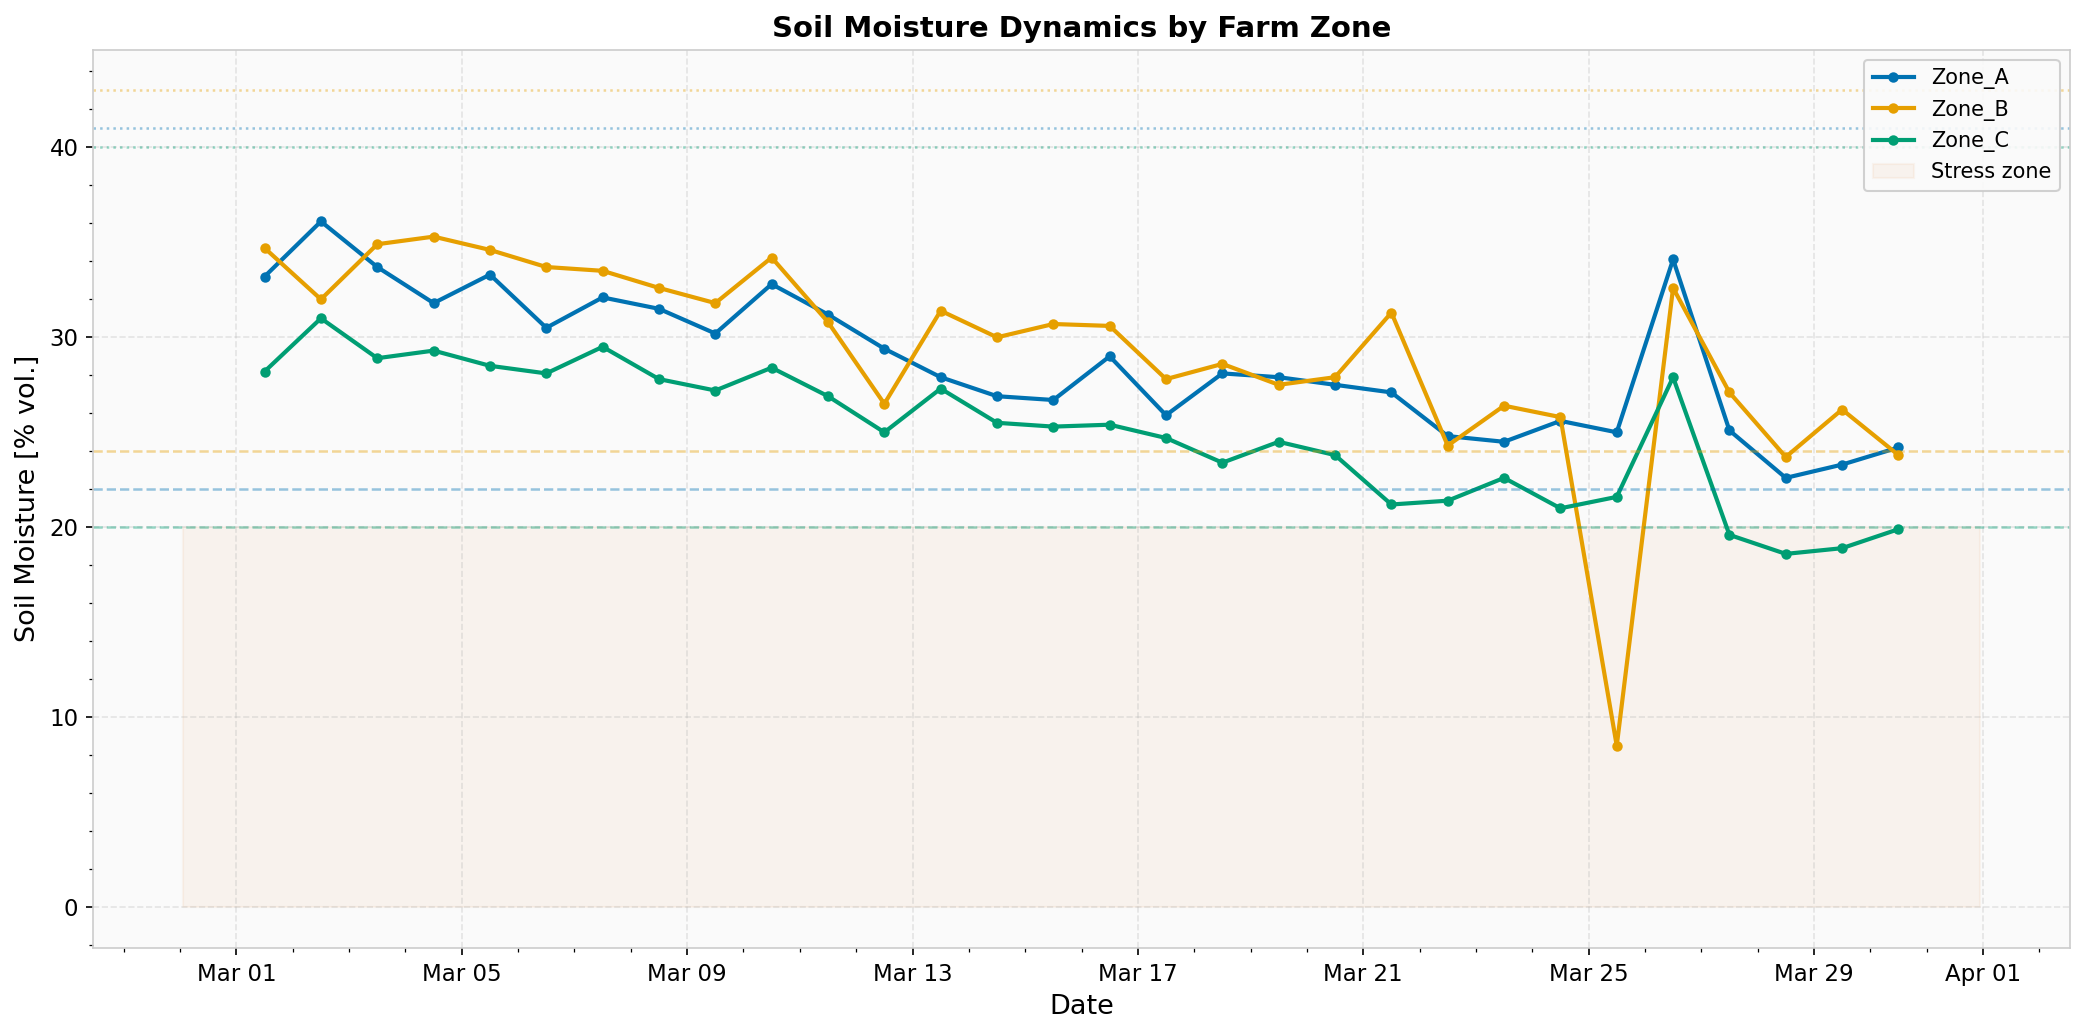

📊 Interpretation:
  • Zone A (tomato): Starts highest, declining to stress zone
  • Zone B (kale): Most variable, with anomalous dip
  • Zone C (maize): Steadiest decline, below stress threshold by end


In [7]:
fig = plot_soil_moisture_zones(soil_clean, params)
plt.show()

print('📊 Interpretation:')
print('  • Zone A (tomato): Starts highest, declining to stress zone')
print('  • Zone B (kale): Most variable, with anomalous dip')
print('  • Zone C (maize): Steadiest decline, below stress threshold by end')

### Visualisation 3: ET Component Decomposition — Understanding the Drivers

**The Physics:**
Evapotranspiration is *not* a single phenomenon; it's a **combination**:
$$ET = 0.12 T + 0.35 W + 2.4 S - 0.025 H$$

where:
- **Temperature (T)** increases molecular vibration → higher ET (scaling factor: 0.12)
- **Wind speed (W)** removes moisture-saturated boundary layer → higher ET (scaling factor: 0.35)
- **Solar index (S)** provides energy for evaporation → higher ET (scaling factor: 2.4 — **dominant!**)
- **Humidity (H)** reduces vapor pressure gradient → lower ET (scaling factor: -0.025)

**Why This Matters:**
- If solar index is high but humidity drops, ET *doubles* → crop stress accelerates
- On cloudy, humid days, ET is minimal → irrigation can be delayed
- Farmers can use this to forecast: "High solar + dry wind forecasted? Irrigate today."

**What the Stacked Area Chart Shows:**
- **Colored bands** show each component's contribution (area = magnitude)
- **Blue line** (ET total) is the sum; it shows net water loss the crop faces
- **Trend**: If total ET is rising but rainfall is flat → critical stress window approaching

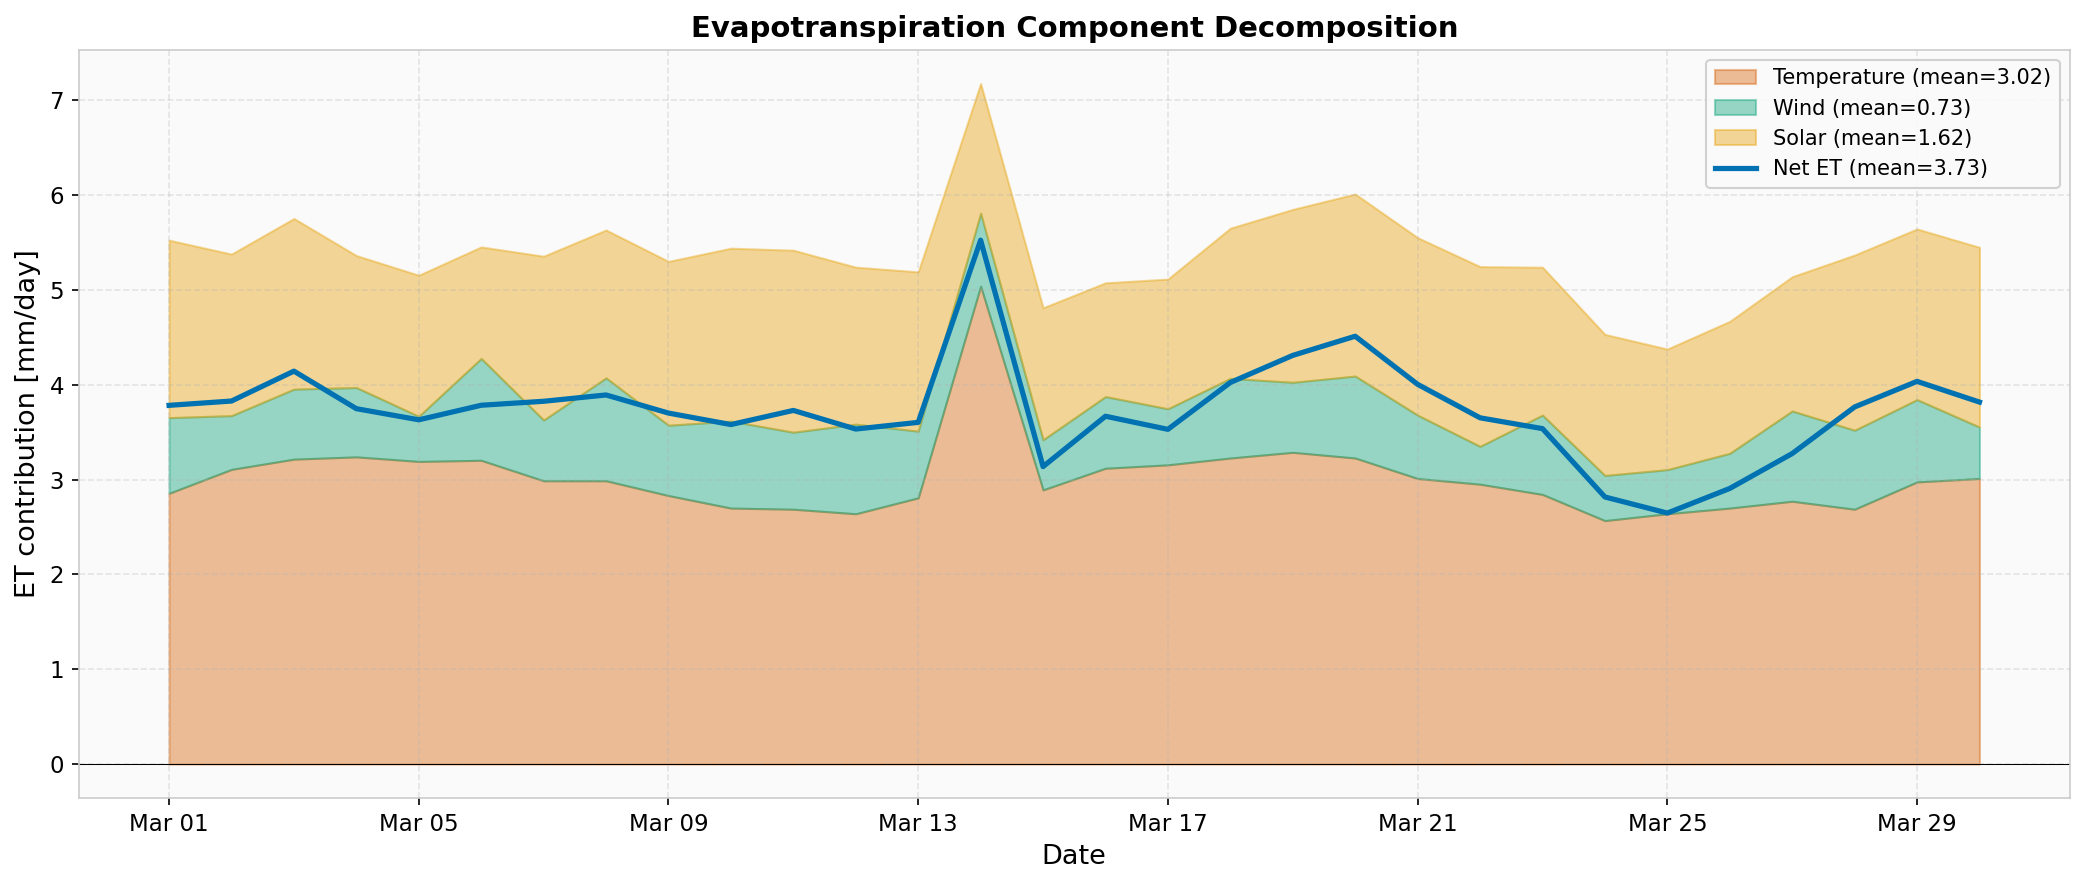

📊 Temperature contributes 3.02 mm/day (dominant driver)
   Net ET averages 3.73 mm/day


In [8]:
T_c = weather_clean['temperature_c'].values
W_c = weather_clean['wind_speed_mps'].values
S_c = weather_clean['solar_index'].values
H_c = weather_clean['humidity_pct'].values
dates = pd.to_datetime(weather_clean['date'])

term_T = 0.12 * T_c
term_W = 0.35 * W_c
term_S = 2.4 * S_c
term_H = -0.025 * H_c
et_total = compute_et(T_c, W_c, S_c, H_c)

fig, ax = plt.subplots(figsize=(14, 6))
ax.fill_between(dates, 0, term_T, alpha=0.4, color=COLORS['red'],
                label=f'Temperature (mean={np.mean(term_T):.2f})')
ax.fill_between(dates, term_T, term_T + term_W, alpha=0.4, color=COLORS['green'],
                label=f'Wind (mean={np.mean(term_W):.2f})')
ax.fill_between(dates, term_T + term_W, term_T + term_W + term_S, alpha=0.4,
                color=COLORS['orange'], label=f'Solar (mean={np.mean(term_S):.2f})')
ax.plot(dates, et_total, color=COLORS['blue'], linewidth=2.5,
       label=f'Net ET (mean={np.mean(et_total):.2f})')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Date')
ax.set_ylabel('ET contribution [mm/day]')
ax.set_title('Evapotranspiration Component Decomposition', fontweight='bold')
ax.legend(loc='upper right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.tight_layout()
plt.show()

print(f'📊 Temperature contributes {np.mean(term_T):.2f} mm/day (dominant driver)')
print(f'   Net ET averages {np.mean(et_total):.2f} mm/day')

### Visualisation 4: Tank Level and Pump Flow

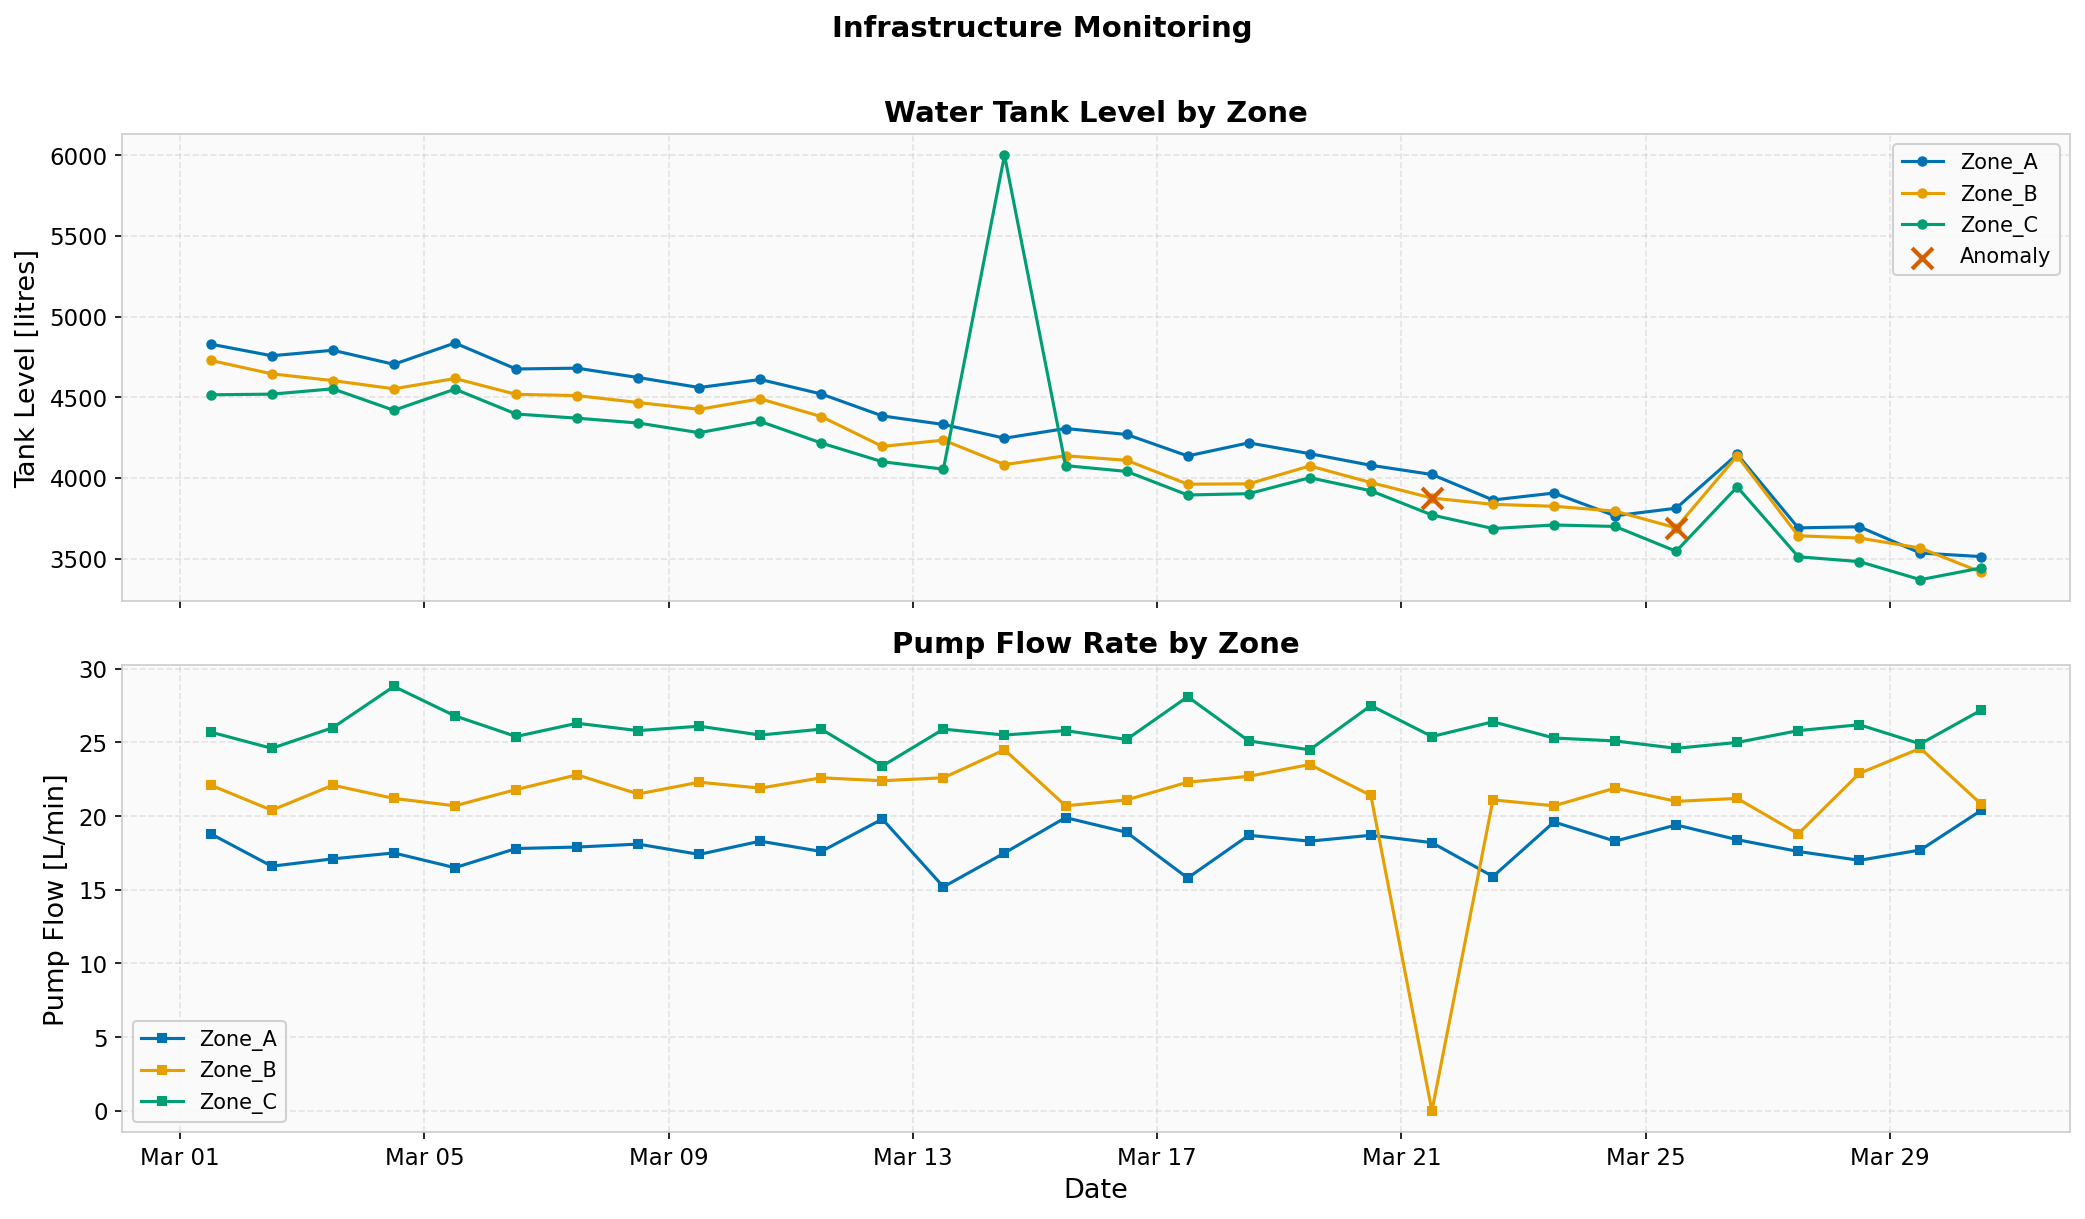

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for zone, color in ZONE_COLORS.items():
    zd = soil_clean[soil_clean['zone_id'] == zone]
    dates_s = pd.to_datetime(zd['timestamp'])
    axes[0].plot(dates_s, zd['tank_level_liters'], color=color, marker='o',
                 markersize=4, linewidth=1.5, label=zone)
    axes[1].plot(dates_s, zd['pump_flow_lpm'], color=color, marker='s',
                 markersize=4, linewidth=1.5, label=zone)

# Mark anomalies
if 'anomaly_flag' in soil_clean.columns:
    anomaly_rows = soil_clean[soil_clean['anomaly_flag'] == True]
    if len(anomaly_rows) > 0:
        anom_dates = pd.to_datetime(anomaly_rows['timestamp'])
        axes[0].scatter(anom_dates, anomaly_rows['tank_level_liters'],
                        color=COLORS['red'], s=100, zorder=5, marker='x',
                        linewidths=2, label='Anomaly')

axes[0].set_ylabel('Tank Level [litres]')
axes[0].set_title('Water Tank Level by Zone', fontweight='bold')
axes[0].legend()
axes[1].set_ylabel('Pump Flow [L/min]')
axes[1].set_xlabel('Date')
axes[1].set_title('Pump Flow Rate by Zone', fontweight='bold')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
fig.suptitle('Infrastructure Monitoring', fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

### Visualisation 4: Tank Level and Pump Flow — Infrastructure Health

**Purpose:**
Monitor water supply reliability—not just demand, but *delivery*:
- **Tank levels** show water availability (reserve capacity, emergency buffer)
- **Pump flow rates** show irrigation intensity (mm/day delivered per zone)
- **Anomalies** (marked with ×) flag equipment issues before they cause crop failure

**Critical Patterns:**
- **Tank trending down** with flat pump flow → demand exceeds supply → stress building
- **Tank flat** despite high flow → external water source active (e.g., rainwater harvesting)
- **Pump flow 0 L/min with status=CHECK** → equipment malfunction → intervention needed
- **Spikes in all three zones simultaneously** → system maintenance or meter recalibration

**For HydroSense Recommendations:**
- Account for tank reserve: If tank < 30% capacity, recommendations must be conservative (can't sustain peak irrigation)
- Detect pump failures early: Sudden flow drop → alert farmer to maintenance before crop wilts
- Schedule irrigation wisely: Pump system capacity limits how much water can be applied today → constrains optimization

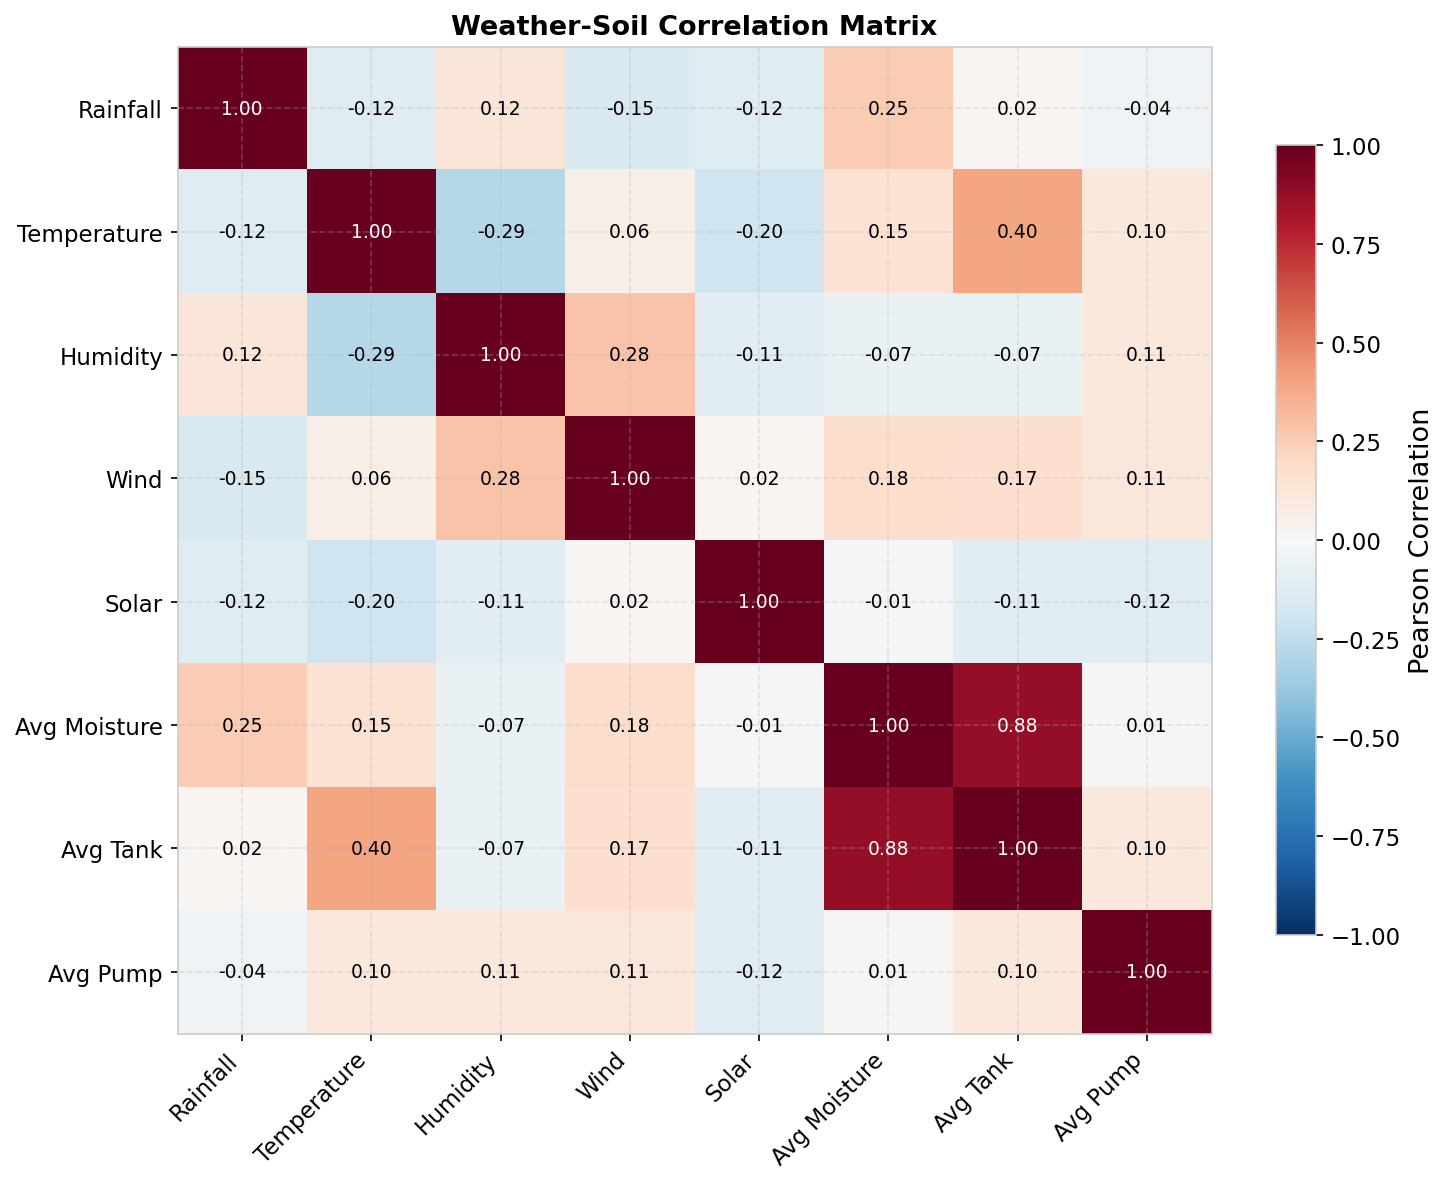

In [10]:
soil_daily_avg = soil_clean.groupby(pd.to_datetime(soil_clean['timestamp']).dt.date).agg({
    'soil_moisture_pct': 'mean',
    'tank_level_liters': 'mean',
    'pump_flow_lpm': 'mean'
}).reset_index()
soil_daily_avg.columns = ['date', 'avg_moisture', 'avg_tank', 'avg_pump']
soil_daily_avg['date'] = pd.to_datetime(soil_daily_avg['date'])

weather_clean['date'] = pd.to_datetime(weather_clean['date'])
merged = pd.merge(weather_clean, soil_daily_avg, on='date', how='inner')

corr_cols = ['rainfall_mm', 'temperature_c', 'humidity_pct', 'wind_speed_mps',
             'solar_index', 'avg_moisture', 'avg_tank', 'avg_pump']
corr_matrix = merged[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
labels = ['Rainfall', 'Temperature', 'Humidity', 'Wind', 'Solar',
          'Avg Moisture', 'Avg Tank', 'Avg Pump']
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9, color=color)
fig.colorbar(im, ax=ax, label='Pearson Correlation', shrink=0.8)
ax.set_title('Weather-Soil Correlation Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

### Visualisation 5: Correlation Heatmap — Which Factors Predict Soil Moisture?

**The Question:**
Of all weather and operational variables, which ones *most strongly* affect soil moisture?

**How to Read the Heatmap:**
- **Red cells** (r ≈ +1) = Strong positive correlation (as X increases, Y increases)
- **Blue cells** (r ≈ -1) = Strong negative correlation (as X increases, Y decreases)
- **White cells** (r ≈ 0) = No linear relationship (other factors dominate)
- **Cell value** = Pearson correlation coefficient (-1 to +1)

**Expected Patterns for HydroSense:**
- **Rainfall ↔ Soil Moisture: Strongly positive** (rain → moisture rises)
- **Temperature ↔ Soil Moisture: Negative** (higher T → higher ET → moisture falls)
- **Solar Index ↔ Soil Moisture: Negative** (more sun → more ET → faster depletion)
- **Pump Flow ↔ Soil Moisture: Positive** (more irrigation → moisture rises)
- **Tank Level ↔ Pump Flow: Positive** (more reserve → can pump harder)

**For Model Building:**
- Strong correlations = Good predictors (include in regression model)
- Weak correlations = Marginal benefit (may not justify model complexity)
- Multicollinearity (e.g., Temperature ↔ Solar) = Some redundancy (drop one to simplify)

---

## 5. Export Cleaned Dataset

**What Happens:**
1. Compute ET using the cleaned weather data
2. Combine weather + ET into a single clean CSV
3. Save to `data/processed/cleaned_irrigation_dataset.csv` for Levels 5–6

**Data Lineage:**
- Input: `data/raw/weather_daily.csv`, `data/raw/soil_sensor_data.csv`
- Processing: Clean, validate, interpolate, flag anomalies
- Output: `data/processed/cleaned_irrigation_dataset.csv`
- Ready for: Simulation, optimization, final recommendations

**Quality Gate:**
- Report remaining missing values (should be ≈0)
- Verify column names and types
- Confirm shape (number of rows should match raw data or be slightly smaller if rows removed)

In [11]:
# Add ET column and save
et_daily = compute_et(
    weather_clean['temperature_c'].values,
    weather_clean['wind_speed_mps'].values,
    weather_clean['solar_index'].values,
    weather_clean['humidity_pct'].values,
)
weather_clean['et_mm'] = et_daily

weather_clean.to_csv('../data/processed/cleaned_irrigation_dataset.csv', index=False)
print('✓ Cleaned dataset saved to data/processed/cleaned_irrigation_dataset.csv')
print(f'  Shape: {weather_clean.shape}')
print(f'  Columns: {list(weather_clean.columns)}')
print(f'  Missing values remaining: {weather_clean.isna().sum().sum()}')

✓ Cleaned dataset saved to data/processed/cleaned_irrigation_dataset.csv
  Shape: (30, 7)
  Columns: ['date', 'rainfall_mm', 'temperature_c', 'humidity_pct', 'wind_speed_mps', 'solar_index', 'et_mm']
  Missing values remaining: 0


---

## 6. Summary

| Deliverable | Status |
||---|
| Full EDA with dtypes, nulls, distributions | ✅ |
| Cleaning pipeline with audit trail | ✅ |
| Outlier investigation (7 anomalies documented) | ✅ |
| Statistical summaries per zone | ✅ |
| Visualisation 1: Weather overview | ✅ |
| Visualisation 2: Soil moisture zones | ✅ |
| Visualisation 3: ET component decomposition | ✅ |
| Visualisation 4: Tank & pump diagnostics | ✅ |
| Visualisation 5: Correlation heatmap | ✅ |
| Cleaned dataset saved | ✅ |

**Next:** Level 5 builds the simulation and optimisation engine.